# Customer Churn — Exploratory Data Analysis

This notebook performs exploratory data analysis on the Telco Customer Churn dataset.

## Objectives

- Understand the dataset structure
- Identify missing values and data-quality issues
- Analyze the churn distribution
- Explore numerical and categorical features
- Investigate relationships between customer characteristics and churn
- Identify useful patterns for model development
- Analyze feature importance for the final trained model

The analysis is performed before production deployment and is intended to support reproducible machine-learning development.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import joblib


# Project paths
ROOT_DIR = Path.cwd().parent

DATA_PATH = ROOT_DIR / "data" / "Telco-Customer-Churn.csv"
MODEL_PATH = ROOT_DIR / "models" / "churn_pipeline.joblib"

RANDOM_STATE = 42

print(f"Project root: {ROOT_DIR}")
print(f"Dataset path: {DATA_PATH}")
print(f"Model path: {MODEL_PATH}")

Project root: /home/captainlevi/customer-churn-mlops
Dataset path: /home/captainlevi/customer-churn-mlops/data/Telco-Customer-Churn.csv
Model path: /home/captainlevi/customer-churn-mlops/models/churn_pipeline.joblib


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Data types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Data types:


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null

In [5]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

print("Missing values:")
display(missing)    

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values after TotalCharges conversion:")

missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing[missing > 0])

Missing values:


Series([], dtype: int64)

Missing values after TotalCharges conversion:


TotalCharges    11
dtype: int64

## Data Quality — Duplicate Records

We check whether the dataset contains duplicate customer records.


In [6]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


## Target Variable — Customer Churn

The target variable is `Churn`.

We examine the distribution of churned and non-churned customers to understand class imbalance.

In [7]:
churn_counts = df["Churn"].value_counts()

print("Churn counts:")
display(churn_counts)

print("\nChurn percentages:")
display(
    (df["Churn"].value_counts(normalize=True) * 100)
    .round(2)
)

Churn counts:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn percentages:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

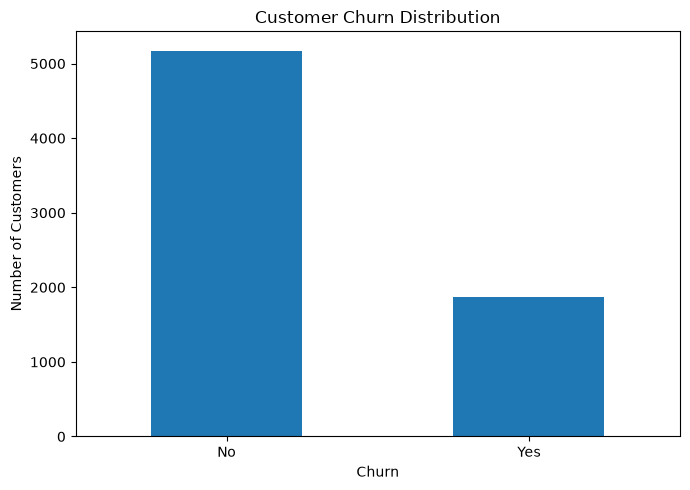

In [8]:
plt.figure(figsize=(7, 5))

churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Numerical Feature Analysis

We analyze the distributions of the numerical customer features:

- Tenure
- Monthly charges
- Total charges

In [9]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

display(
    df[numerical_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


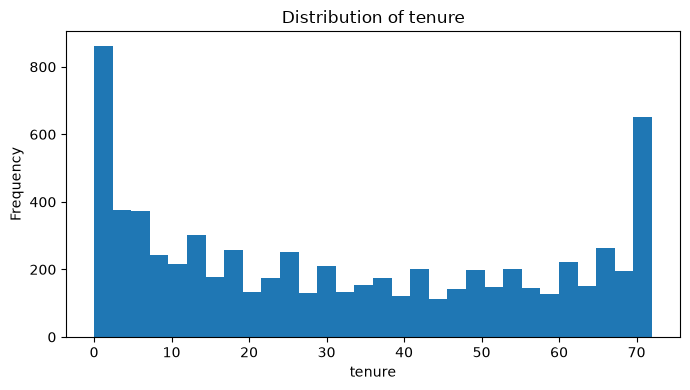

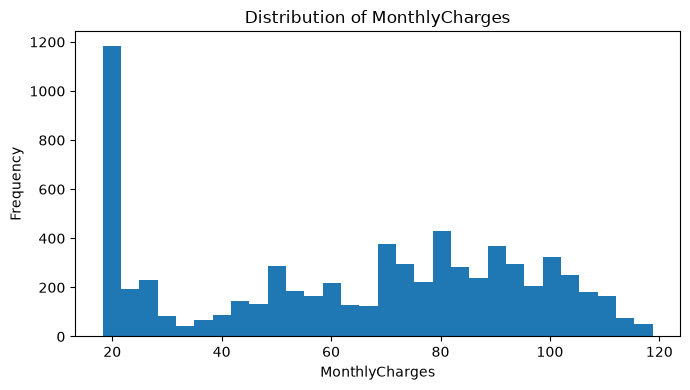

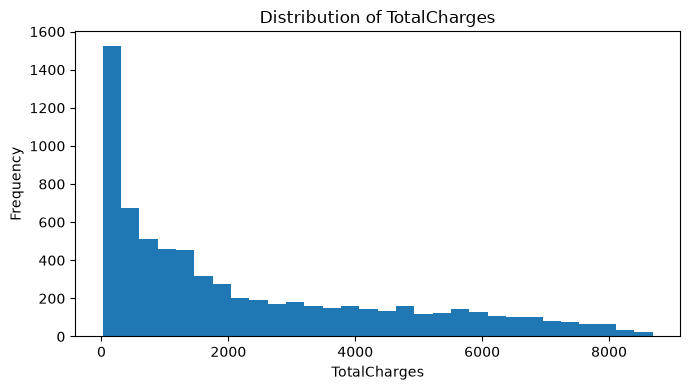

In [10]:
for feature in numerical_features:

    plt.figure(figsize=(7, 4))

    df[feature].plot(
        kind="hist",
        bins=30,
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## Numerical Features vs Churn

We compare numerical customer characteristics between churned and retained customers.

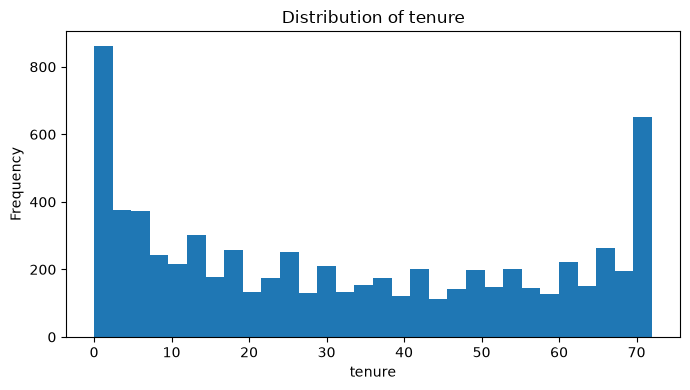

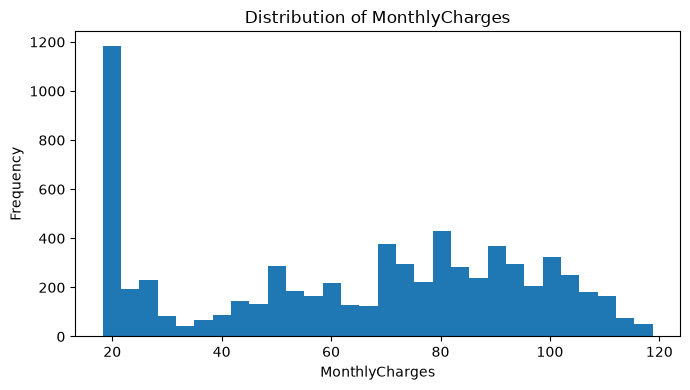

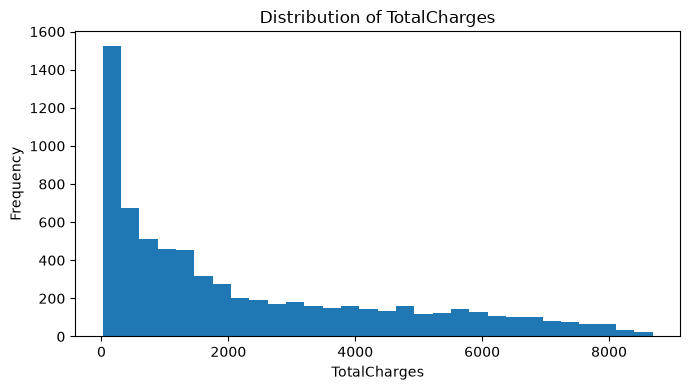

In [20]:
for feature in numerical_features:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[feature].dropna(),
        bins=30
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [12]:
display(
    df.groupby("Churn")[numerical_features]
    .mean()
    .round(2)
)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


In [13]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

## Categorical Feature Analysis

We examine how customer churn varies across important categorical attributes.

In [14]:
for feature in categorical_features:

    churn_rate = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{feature}")
    display(churn_rate.round(2))


gender


gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64


SeniorCitizen


SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64


Partner


...

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


PaperlessBilling


PaperlessBilling
Yes    33.57
No     16.33
Name: Churn, dtype: float64


PaymentMethod


PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

## Churn Rate by Important Categorical Features

The categorical analysis shows substantial differences in churn rates across contract type, internet service, payment method, and support/security services.

We visualize the most important relationships to make these patterns easier to interpret.

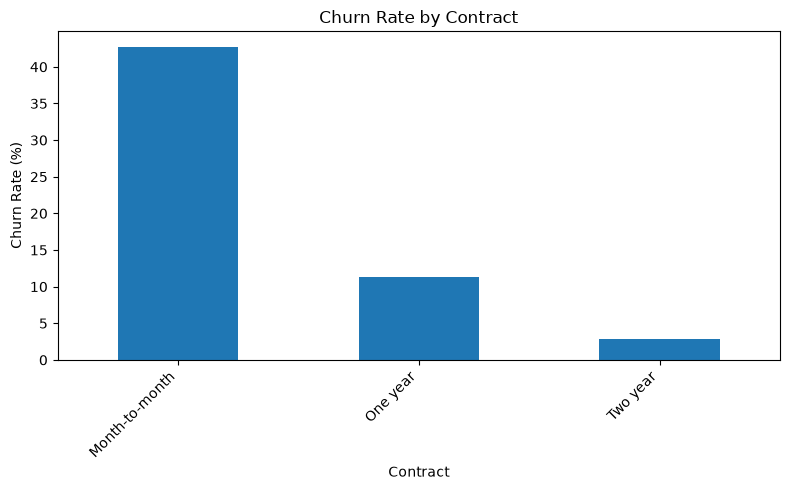

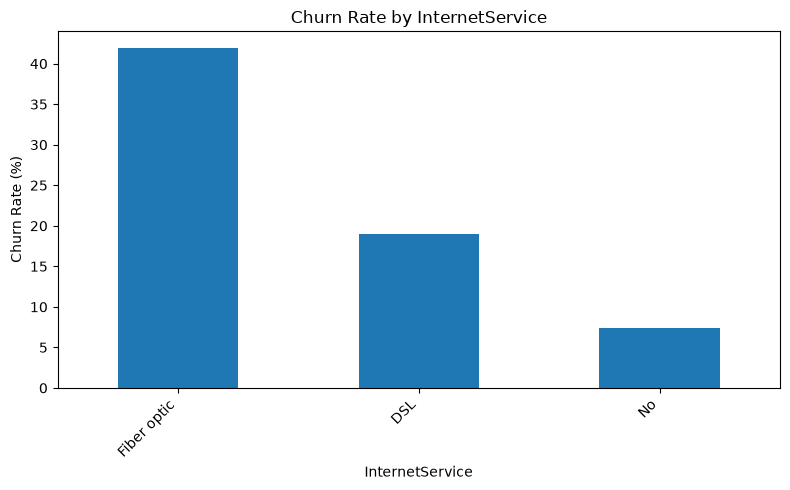

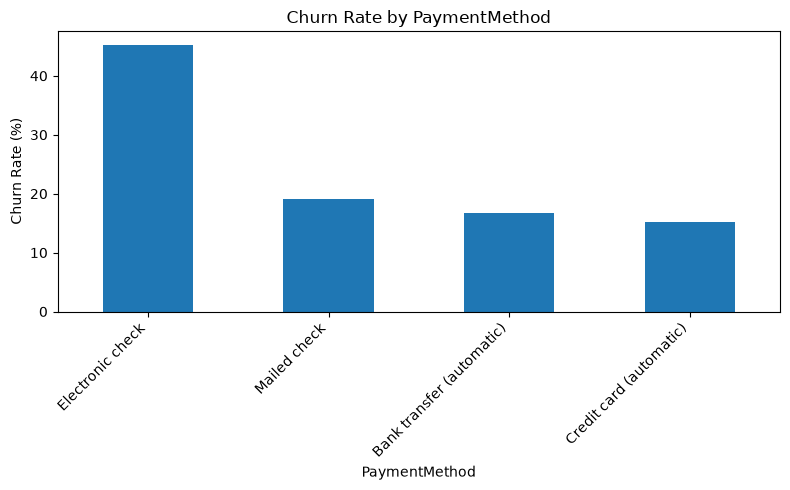

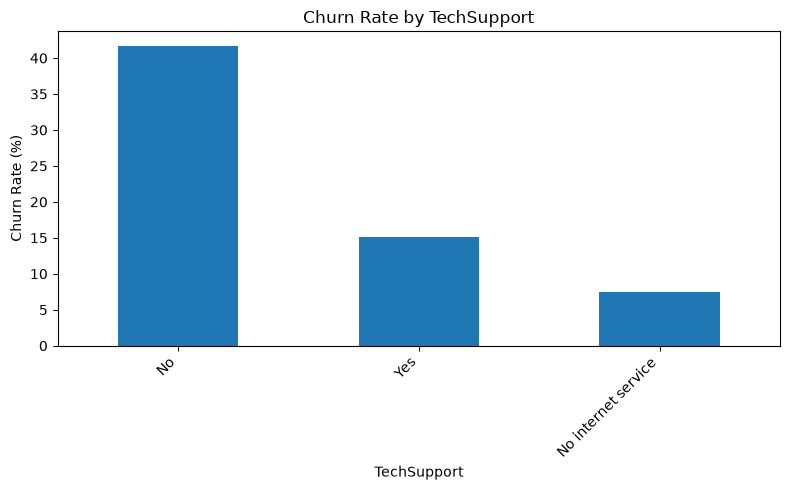

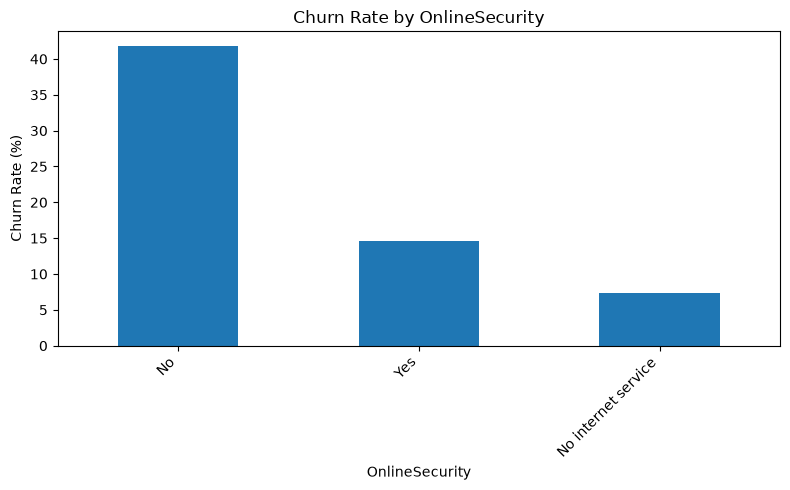

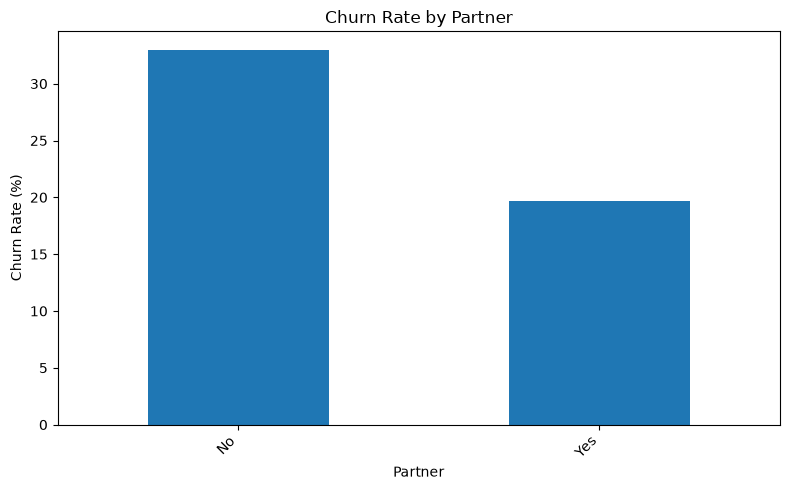

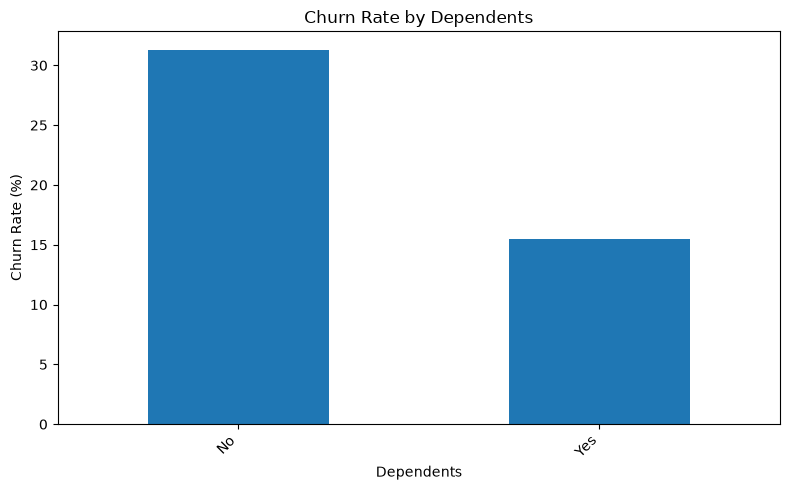

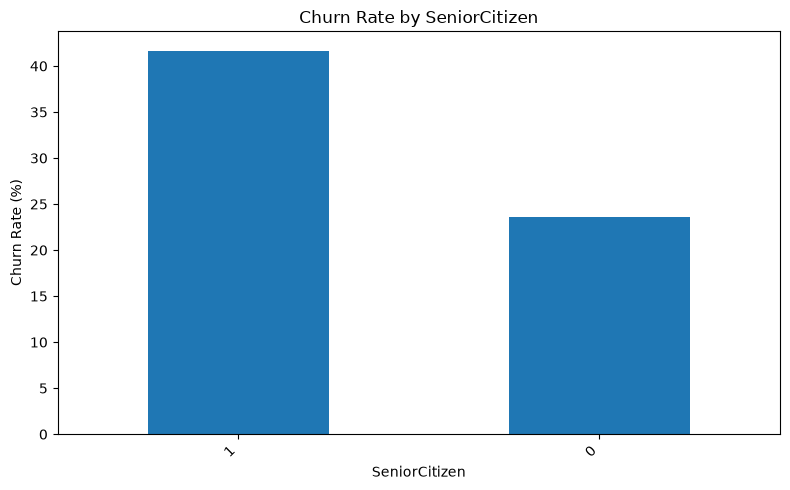

In [15]:
important_categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "Partner",
    "Dependents",
    "SeniorCitizen",
]

for feature in important_categorical_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))
    churn_rate.plot(kind="bar")

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Correlation Analysis

Correlation analysis is used to understand relationships between numerical variables.

Because `Churn` is categorical, it is converted to a binary representation for this analysis.

In [17]:
correlation_df = df.copy()

correlation_df["Churn"] = (
    correlation_df["Churn"]
    .map({"No": 0, "Yes": 1})
)

correlation_matrix = correlation_df[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].corr()

display(correlation_matrix.round(3))

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.199
Churn,-0.352,0.193,-0.199,1.000


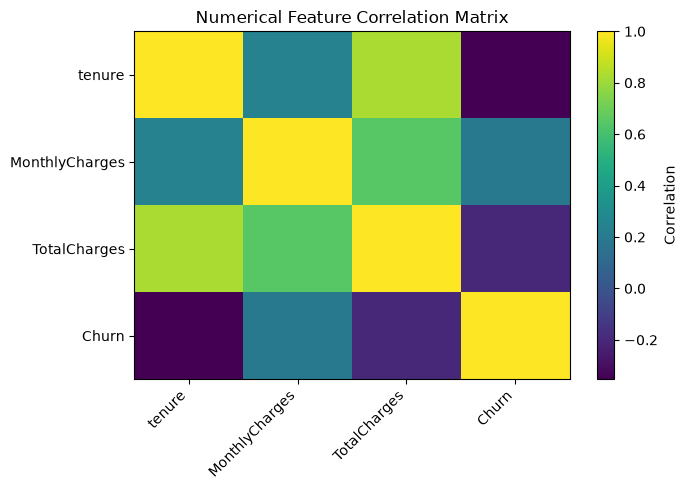

In [18]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## Churn Rate by Important Categorical Features

The categorical analysis identified substantial differences in churn rates across contract type, internet service, payment method, and customer support/security services.

These relationships are visualized below to make the most important patterns easier to interpret.

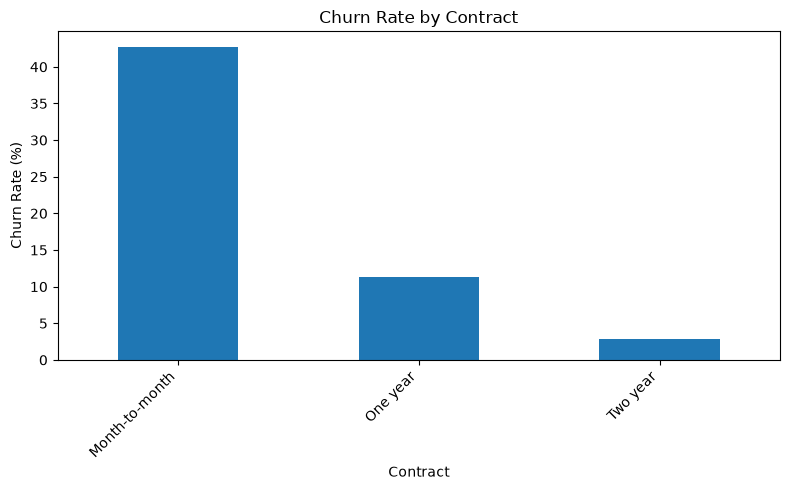

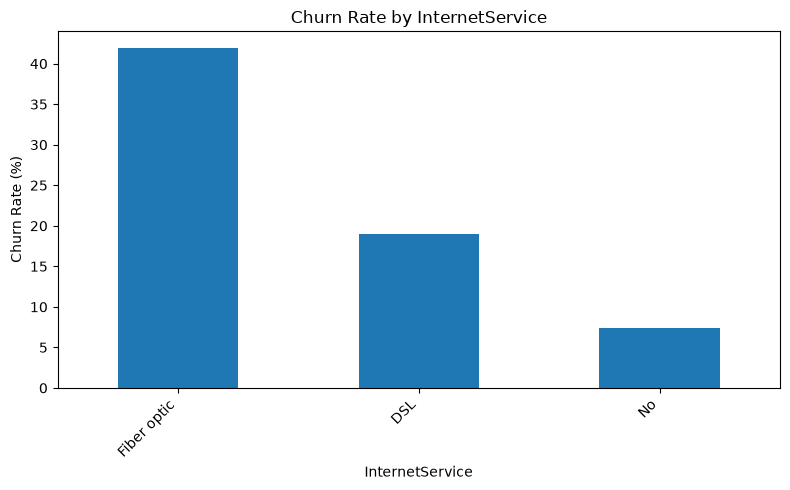

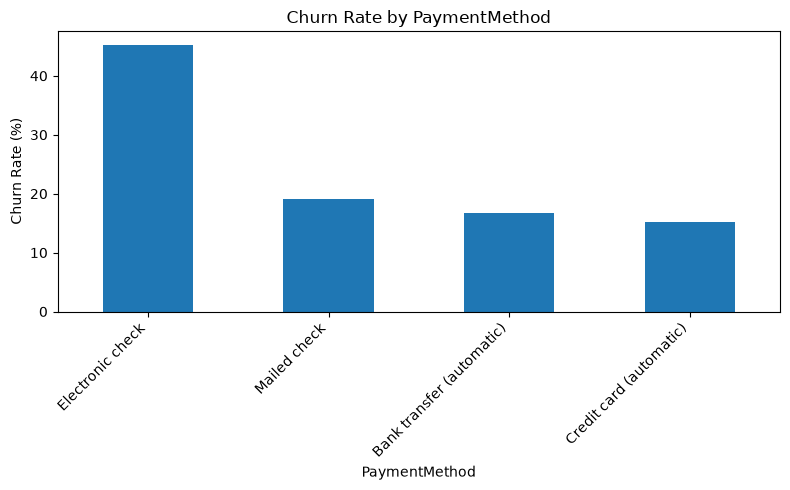

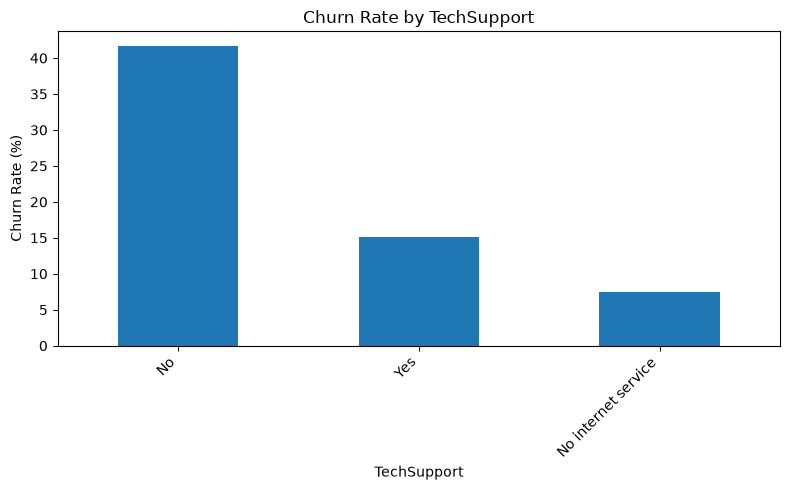

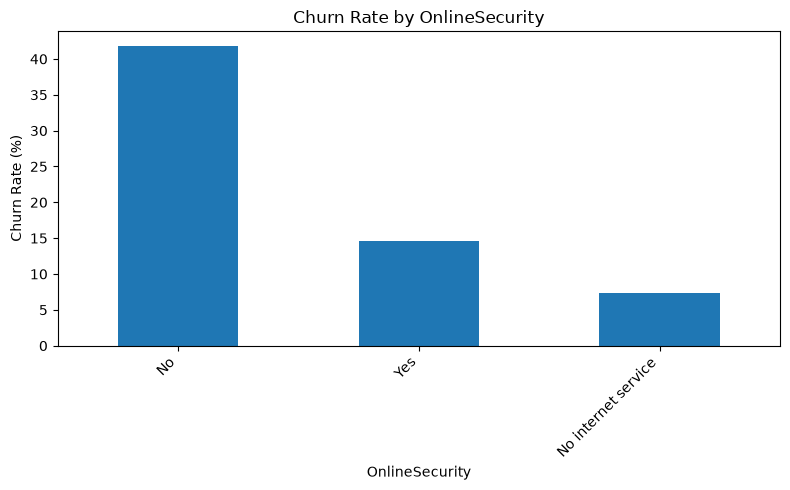

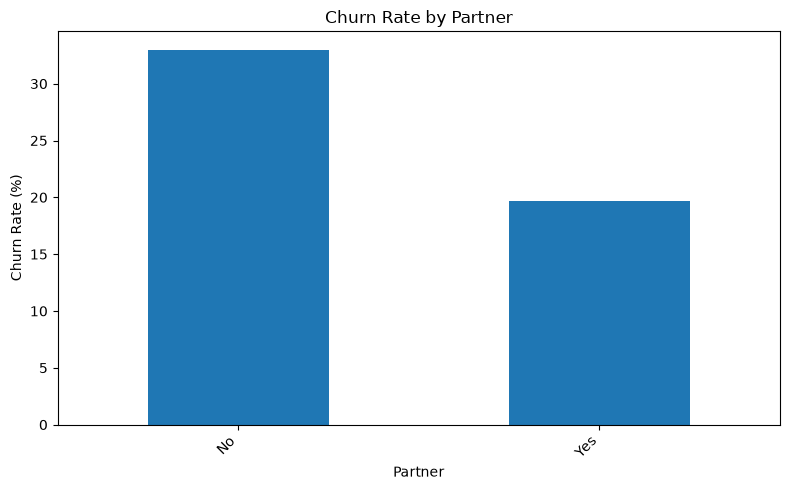

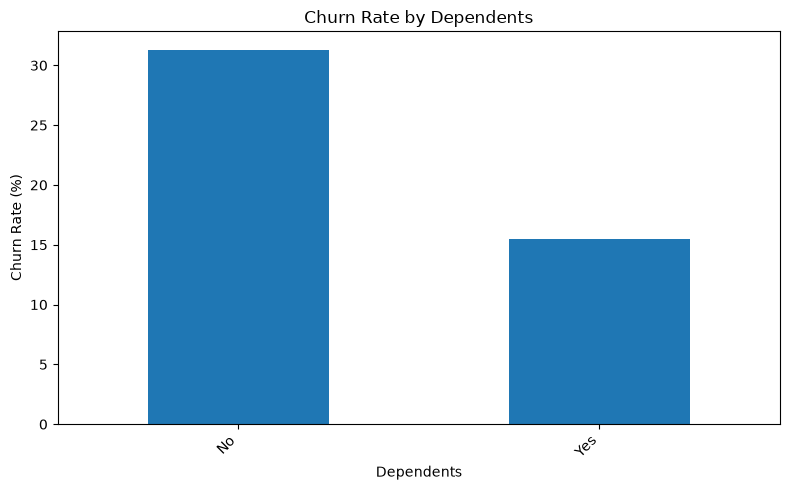

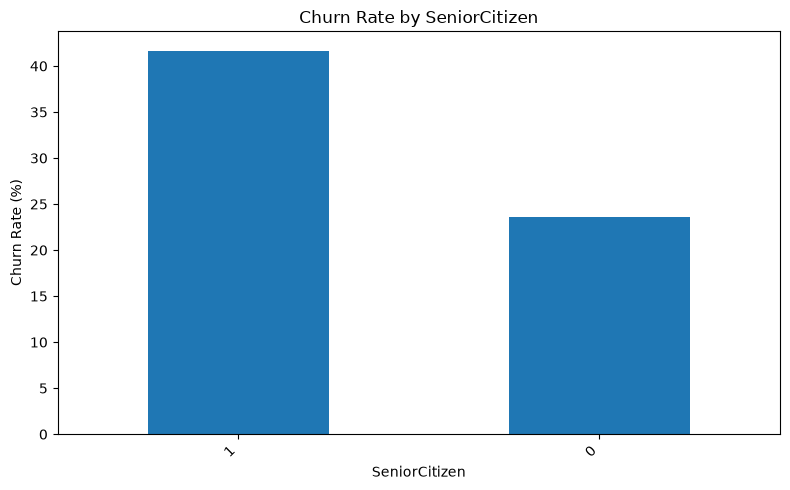

In [19]:
important_categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "Partner",
    "Dependents",
    "SeniorCitizen",
]

for feature in important_categorical_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))
    churn_rate.plot(kind="bar")

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Correlation Analysis

Correlation analysis is used to understand relationships between numerical variables.

The categorical target `Churn` is converted into a binary representation for this analysis.

In [21]:
correlation_df = df.copy()

correlation_df["Churn"] = (
    correlation_df["Churn"]
    .map({"No": 0, "Yes": 1})
)

correlation_matrix = correlation_df[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].corr()

display(correlation_matrix.round(3))

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.199
Churn,-0.352,0.193,-0.199,1.000


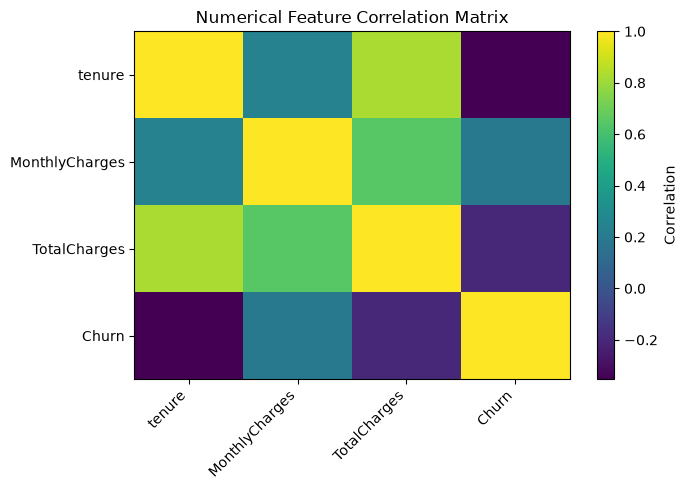

In [22]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## Model Feature Importance

Permutation feature importance is used to understand which original customer features contribute most to the trained churn model's performance.

The analysis is performed on the held-out test set using F1 score, which matches the metric used for decision-threshold optimization.

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import joblib

# Prepare model data
model_df = df.copy()

model_df = model_df.drop(columns=["customerID"])

model_df["TotalCharges"] = pd.to_numeric(
    model_df["TotalCharges"],
    errors="coerce"
)

model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

model = joblib.load(MODEL_PATH)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 5634
Test samples: 1409


In [24]:
importance = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values(
    "importance_mean",
    ascending=False
)

display(importance_df.head(15).round(4))

,feature,importance_mean,importance_std
14,Contract,0.0657,0.0129
4,tenure,0.0611,0.0051
7,InternetService,0.0199,0.0095
11,TechSupport,0.0062,0.0051
18,TotalCharges,0.0032,0.0023
8,OnlineSecurity,0.0014,0.0041
12,StreamingTV,0.0011,0.0020
2,Partner,0.0000,0.0000
10,DeviceProtection,-0.0003,0.0006
0,gender,-0.0003,0.0003


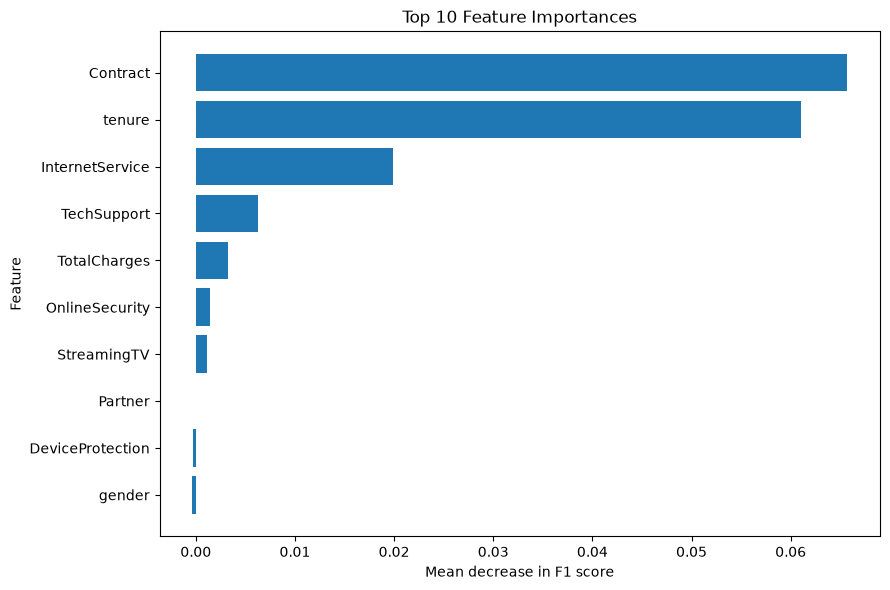

In [25]:
top_features = importance_df.head(10).sort_values(
    "importance_mean"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Mean decrease in F1 score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

## Key Findings and Modeling Implications

### Dataset Quality

- The dataset contains 7,043 customers and 21 original columns.
- No duplicate records were identified.
- `TotalCharges` required conversion from text to numeric.
- The conversion revealed 11 missing values.

### Target Distribution

- 73.46% of customers did not churn.
- 26.54% of customers churned.
- The target is therefore imbalanced, making accuracy alone insufficient for evaluating the model.

### Numerical Features

- Churned customers have substantially lower average tenure.
- Churned customers have higher average monthly charges.
- Total charges are lower for churned customers, consistent with shorter customer tenure.

### Categorical Features

The strongest observed differences in churn rate include:

- Contract type
- Internet service
- Payment method
- Technical support
- Online security
- Customer relationship characteristics

Month-to-month contracts and electronic-check payments show particularly high churn rates.

### Modeling Implications

The EDA supports:

- stratified train/test splitting
- class-imbalance handling
- comparison of multiple classification algorithms
- hyperparameter tuning
- F1-based threshold optimization
- model feature-importance analysis

These findings are used to guide the subsequent machine-learning and MLOps stages.